In [8]:
data = "US_Accidents_March23.csv"

In [420]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, mean_absolute_error
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

In [12]:
df = pd.read_csv(data)

In [13]:
df

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.010,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.010,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.002480,-117.379360,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.766960,-117.148060,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.775450,-117.847790,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.992460,-118.403020,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day


In [15]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [18]:
len(df.columns)

46

In [20]:
len(df)

7728394

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [24]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [26]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_df = df.select_dtypes(include=numerics)
len(numeric_df.columns)

13

# DATA PREPROCESSING AND CLEANING

## Check the number of null values per column

In [29]:
df.isna().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [32]:
df.duplicated().sum()

0

In [34]:
#FILLING MISSING VALUES
df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [36]:
df.fillna(method='ffill', limit=5, inplace=True)
df.fillna(method='bfill', limit=5, inplace=True)

/var/folders/5n/qzct1z617dnd0psd314ndx3w0000gn/T/ipykernel_24931/1041787634.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', limit=5, inplace=True)
/var/folders/5n/qzct1z617dnd0psd314ndx3w0000gn/T/ipykernel_24931/1041787634.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', limit=5, inplace=True)


In [38]:
df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402757
End_Lng                  3402757
Distance(mi)                   0
Description                    0
Street                         0
City                           0
County                         0
State                          0
Zipcode                        0
Country                        0
Timezone                       0
Airport_Code                   0
Weather_Timestamp           4024
Temperature(F)              4035
Wind_Chill(F)            1417136
Humidity(%)                 4068
Pressure(in)                4033
Visibility(mi)              4032
Wind_Direction              4040
Wind_Speed(mph)            11197
Precipitation(in)        1368847
Weather_Condition           4024
Amenity                        0
Bump      

In [40]:
# DROP COLUMNS
df.drop(columns=['End_Lat', 'End_Lng'],inplace= True)

In [42]:
df.dropna(subset=['Wind_Chill(F)','Wind_Speed(mph)','Precipitation(in)'],inplace = True)

In [44]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [46]:
df.isnull().sum()

ID                       0
Source                   0
Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
Distance(mi)             0
Description              0
Street                   0
City                     0
County                   0
State                    0
Zipcode                  0
Country                  0
Timezone                 0
Airport_Code             0
Weather_Timestamp        0
Temperature(F)           0
Wind_Chill(F)            0
Humidity(%)              0
Pressure(in)             9
Visibility(mi)           7
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
T

## OUTLIERS

In [48]:
df.describe()

,Severity,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,5.940949e+06,5.940949e+06,5.940949e+06,5.940949e+06,5.940949e+06,5.940949e+06,5.940949e+06,5.940940e+06,5.940942e+06,5.940949e+06,5.940949e+06
mean,2.165517e+00,3.624661e+01,-9.471702e+01,6.569173e-01,6.076147e+01,5.901370e+01,6.508220e+01,2.938636e+01,8.996033e+00,7.432872e+00,9.004327e-03
std,4.617203e-01,5.128315e+00,1.753344e+01,1.872193e+00,1.934344e+01,2.189954e+01,2.296034e+01,1.099895e+00,2.675416e+00,5.536145e+00,1.624373e-01
min,1.000000e+00,2.455480e+01,-1.245481e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.345783e+01,-1.172779e+02,0.000000e+00,4.800000e+01,4.400000e+01,4.800000e+01,2.920000e+01,1.000000e+01,3.000000e+00,0.000000e+00
50%,2.000000e+00,3.595733e+01,-8.745248e+01,8.900000e-02,6.300000e+01,6.300000e+01,6.800000e+01,2.972000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.012607e+01,-8.031343e+01,6.160000e-01,7.600000e+01,7.600000e+01,8.500000e+01,2.997000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.748413e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [51]:
OutliersColumns = ["Start_Lat","Start_Lng"]

In [79]:
sampled_dff = df.sample(frac=0.1, random_state=42)
sampled_dff.dropna(inplace=True)
categorical_cols = sampled_dff.select_dtypes(include=['object','bool','category']).columns
label_encoder = LabelEncoder()

for col in categorical_cols:
    sampled_dff[col] = label_encoder.fit_transform(sampled_dff[col])
    
X = sampled_dff.drop('Severity', axis=1)
y= sampled_dff['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

rf_classifier = RandomForestClassifier()

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

# print(classification_task(rf_classifier,X_train, y_train ,X_test,y_test, y_pred,'rf'))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall:.2f}")

confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_mat)

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Calculate Error Ratio
error_ratio = 1 - accuracy
print(f"Error Ratio: {error_ratio:.2f}")

Accuracy: 0.93
Precision: 0.93
Recall: 0.93
Confusion Matrix:
[[  1297    624     93      0]
 [   251 146017   3112    199]
 [    33   5023  16846     10]
 [     1   2578    387   1757]]
Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.64      0.72      2014
           2       0.95      0.98      0.96    149579
           3       0.82      0.77      0.80     21912
           4       0.89      0.37      0.53      4723

    accuracy                           0.93    178228
   macro avg       0.87      0.69      0.75    178228
weighted avg       0.93      0.93      0.93    178228

Error Ratio: 0.07


In [91]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 0.08537379087461006


# FEATURE ENGINEERING

In [99]:
df2= df.copy()

## DROPPING COLUMN

In [103]:
df2.drop(columns =['Description','Country','Turning_Loop','ID'],inplace = True)

In [105]:
sampled_dff = df2.sample(frac=0.1, random_state=42)

sampled_dff.dropna(inplace=True)

categorical_cols = sampled_dff.select_dtypes(include=['object','bool','category']).columns
label_encoder = LabelEncoder()
for col in categorical_cols:
    sampled_dff[col] = label_encoder.fit_transform(sampled_dff[col])
    
X = sampled_dff.drop('Severity', axis=1)
y= sampled_dff['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

rf_classifier = RandomForestClassifier()

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

# print(classification_task(rf_classifier,X_train, y_train ,X_test,y_test, y_pred,'rf'))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall:.2f}")

confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_mat)

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Calculate Error Ratio
error_ratio = 1 - accuracy
print(f"Error Ratio: {error_ratio:.2f}")

Accuracy: 0.91
Precision: 0.90
Recall: 0.91
Confusion Matrix:
[[  1227    649    135      3]
 [   368 144698   4111    402]
 [   105   6720  14976    111]
 [     8   3369    521    825]]
Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.61      0.66      2014
           2       0.93      0.97      0.95    149579
           3       0.76      0.68      0.72     21912
           4       0.62      0.17      0.27      4723

    accuracy                           0.91    178228
   macro avg       0.76      0.61      0.65    178228
weighted avg       0.90      0.91      0.90    178228

Error Ratio: 0.09


In [114]:
# Select features that are suitable for One Hot Encoding
one_hot_features = ['Wind_Direction', 'Weather_Condition']

# Wind_Direction Categorizing
df2.loc[df2['Wind_Direction'].str.startswith('C'), 'Wind_Direction'] = 'C' #Calm
df2.loc[df2['Wind_Direction'].str.startswith('E'), 'Wind_Direction'] = 'E' #East, ESE, ENE
df2.loc[df2['Wind_Direction'].str.startswith('W'), 'Wind_Direction'] = 'W' #West, WSW, WNW
df2.loc[df2['Wind_Direction'].str.startswith('S'), 'Wind_Direction'] = 'S' #South, SSW, SSE
df2.loc[df2['Wind_Direction'].str.startswith('N'), 'Wind_Direction'] = 'N' #North, NNW, NNE
df2.loc[df2['Wind_Direction'].str.startswith('V'), 'Wind_Direction'] = 'V' #Variable

In [120]:
df2['Start_Time']

0          2016-02-08 05:46:00
1          2016-02-08 06:07:59
2          2016-02-08 06:49:27
3          2016-02-08 07:23:34
4          2016-02-08 07:39:07
                  ...         
7728389    2019-08-23 18:03:25
7728390    2019-08-23 19:11:30
7728391    2019-08-23 19:00:21
7728392    2019-08-23 19:00:21
7728393    2019-08-23 18:52:06
Name: Start_Time, Length: 5940949, dtype: object

In [122]:
df2[['Start_Date', 'Start_Time']] = df2['Start_Time'].str.split(' ',expand=True)

In [124]:
df2['Start_Date']

0          2016-02-08
1          2016-02-08
2          2016-02-08
3          2016-02-08
4          2016-02-08
              ...    
7728389    2019-08-23
7728390    2019-08-23
7728391    2019-08-23
7728392    2019-08-23
7728393    2019-08-23
Name: Start_Date, Length: 5940949, dtype: object

In [126]:
df2['Start_Date'] = pd.to_datetime(df2['Start_Date'], format="%Y-%m-%d")

In [128]:
df2['Start_Time']

0          05:46:00
1          06:07:59
2          06:49:27
3          07:23:34
4          07:39:07
             ...   
7728389    18:03:25
7728390    19:11:30
7728391    19:00:21
7728392    19:00:21
7728393    18:52:06
Name: Start_Time, Length: 5940949, dtype: object

In [130]:
df2['Start_Time'] = df2['Start_Time'].astype(str).str.replace('0 days ', '')
df2['Start_Time']

0          05:46:00
1          06:07:59
2          06:49:27
3          07:23:34
4          07:39:07
             ...   
7728389    18:03:25
7728390    19:11:30
7728391    19:00:21
7728392    19:00:21
7728393    18:52:06
Name: Start_Time, Length: 5940949, dtype: object

In [132]:
df2['Start_month'] = df2['Start_Date'].dt.month
df2['Start_day'] = df2['Start_Date'].dt.day
df2['Start_year'] = df2['Start_Date'].dt.year

In [134]:
df2[['Start_month','Start_day','Start_year']].head()

,Start_month,Start_day,Start_year
0,2,8,2016
1,2,8,2016
2,2,8,2016
3,2,8,2016
4,2,8,2016


In [ ]:
df2['Start_Time'] = pd.to_timedelta(df2['Start_Time'])

In [144]:
df2[['End_Date', 'End_Time']] = df2['End_Time'].str.split(' ',expand=True)

In [145]:
df2['End_Date'] = pd.to_datetime(df2['End_Date'], format="%Y-%m-%d")

In [148]:
df2['End_Time'] = pd.to_timedelta(df2['End_Time'])

In [159]:
df2['End_month'] = df2['End_Date'].dt.month
df2['End_day'] = df2['End_Date'].dt.day
df2['End_year'] = df2['End_Date'].dt.year

In [161]:
df2[['Weather_Date', 'Weather_Time']] = df2['Weather_Timestamp'].str.split(' ',expand=True)

In [163]:
df2['Weather_Date'] = pd.to_datetime(df2['Weather_Date'], format="%Y-%m-%d")

In [165]:
df2['Weather_Time'] = pd.to_timedelta(df2['Weather_Time'])

In [167]:
df2['End_month'] = df2['End_Date'].dt.month
df2['End_day'] = df2['End_Date'].dt.day
df2['End_year'] = df2['End_Date'].dt.year

In [169]:
df2['Weather_month'] = df2['Weather_Date'].dt.month
df2['Weather_day'] = df2['Weather_Date'].dt.day
df2['Weather_year'] = df2['Weather_Date'].dt.year

In [171]:
parts = df2['Start_Time'].astype(str).str.split(':')

df2['Start_Hour'] = parts.str[0]
df2['Start_Mins'] = parts.str[1]
df2['Start_seconds'] = parts.str[2]

In [172]:
df2[['Start_Hour','Start_Mins','Start_seconds']].head()

,Start_Hour,Start_Mins,Start_seconds
0,05,46,00
1,06,07,59
2,06,49,27
3,07,23,34
4,07,39,07


In [179]:
parts = df2['End_Time'].astype(str).str.split(':')

df2['End_Hour'] = parts.str[0]
df2['End_Mins'] = parts.str[1]
df2['End_seconds'] = parts.str[2]

In [180]:
parts = df2['Weather_Time'].astype(str).str.split(':')

df2['Weather_Hour'] = parts.str[0]
df2['Weather_Mins'] = parts.str[1]
df2['Weather_seconds'] = parts.str[2]

In [177]:
df2.head()

,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,County,...,End_day,End_year,Weather_Date,Weather_Time,Weather_month,Weather_day,Weather_year,Start_Hour,Start_Mins,Start_seconds
0,Source2,3,05:46:00,0 days 11:00:00,39.865147,-84.058723,0.01,I-70 E,Dayton,Montgomery,...,8,2016,2016-02-08,0 days 05:58:00,2,8,2016,05,46,00
1,Source2,2,06:07:59,0 days 06:37:59,39.928059,-82.831184,0.01,Brice Rd,Reynoldsburg,Franklin,...,8,2016,2016-02-08,0 days 05:51:00,2,8,2016,06,07,59
2,Source2,2,06:49:27,0 days 07:19:27,39.063148,-84.032608,0.01,State Route 32,Williamsburg,Clermont,...,8,2016,2016-02-08,0 days 06:56:00,2,8,2016,06,49,27
3,Source2,3,07:23:34,0 days 07:53:34,39.747753,-84.205582,0.01,I-75 S,Dayton,Montgomery,...,8,2016,2016-02-08,0 days 07:38:00,2,8,2016,07,23,34
4,Source2,2,07:39:07,0 days 08:09:07,39.627781,-84.188354,0.01,Miamisburg Centerville Rd,Dayton,Montgomery,...,8,2016,2016-02-08,0 days 07:53:00,2,8,2016,07,39,07


In [201]:
df_numerical = df.select_dtypes(include=['int64','float64'])

<Axes: >

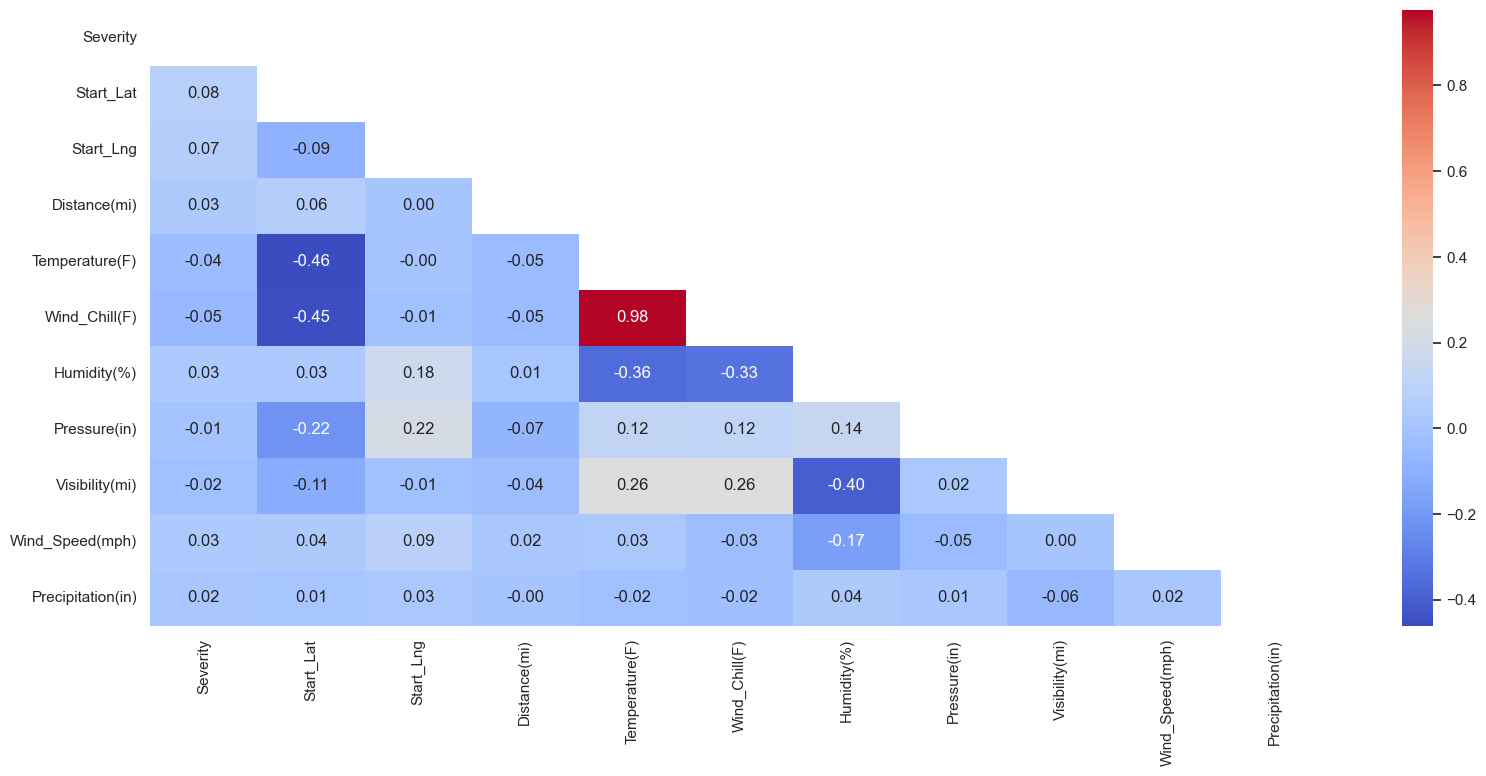

In [203]:
plt.figure(figsize=(19, 8))
sns.set(style="white") 
mask = np.triu(df_numerical.corr()) 
sns.heatmap(data=df_numerical.corr(), annot=True, fmt=".2f", cmap='coolwarm', mask=mask)

# MODEL SELECTION

FOR CLASSIFICATION (ACCIDENT SEVERITY PREDICTION)

In [245]:
def classification_task( model,X_train_scaled, y_train ,X_test_scaled ,y_test, predic,model_name):
 
    perf_df=pd.DataFrame({'Train_Score':model.score(X_train_scaled,y_train),"Test_Score":model.score(X_test_scaled,y_test),
                       "Precision_Score":precision_score(y_test,predic,average='weighted'),"Recall_Score":recall_score(y_test,predic,average='weighted'),
                       "F1_Score":f1_score(y_test,predic,average='weighted') , "accuracy":accuracy_score(y_test,predic)}, index=[model_name])
    return perf_df

## LOGISTIC REGRESSION

In [223]:
sam= RandomUnderSampler(random_state=0)
X_resampled_under , y_resampled_under = sam.fit_resample(X,y)
y_resampled_under.value_counts()

Severity
1    6682
2    6682
3    6682
4    6682
Name: count, dtype: int64

In [231]:
X_resampled_under, X_test_resampled, y_resampled_under, y_test_resampled = train_test_split(X_resampled_under, y_resampled_under, test_size=0.30, random_state=42)

In [233]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled_under)
X_test_scaled = scaler.transform(X_test_resampled)

In [235]:
logistic_regression = LogisticRegression(random_state=42)
logistic_regression.fit(X_train_scaled, y_resampled_under)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [257]:
y_pred = logistic_regression.predict(X_test_scaled)
Eval_logreg=classification_task(logistic_regression,X_train_scaled, y_resampled_under ,X_test_scaled,y_test_resampled, y_pred,'logreg')
Eval_logreg

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
logreg,0.63401,0.636558,0.630243,0.636558,0.630501,0.636558


Accuracy: 0.64


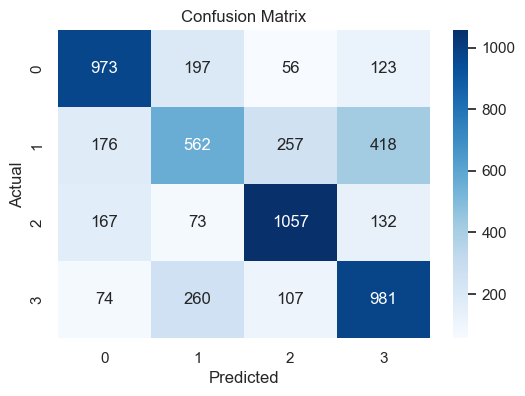

Classification Report:
              precision    recall  f1-score   support

           1       0.70      0.72      0.71      1349
           2       0.51      0.40      0.45      1413
           3       0.72      0.74      0.73      1429
           4       0.59      0.69      0.64      1422

    accuracy                           0.64      5613
   macro avg       0.63      0.64      0.63      5613
weighted avg       0.63      0.64      0.63      5613



In [282]:
accuracy = accuracy_score(y_test_resampled, y_pred)
print(f"Accuracy: {accuracy:.2f}")


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_resampled, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_test_resampled, y_pred)
print("Classification Report:")
print(class_report)

## DECISION TREE

In [292]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_resampled_under, y_resampled_under)

DecisionTreeClassifier(random_state=42)

In [294]:
y_pred = dt_classifier.predict(X_test_resampled)
Eval_Dt=classification_task(dt_classifier,X_resampled_under, y_resampled_under ,X_test_resampled ,y_test_resampled, y_pred,'Decision Trees')
Eval_Dt

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
Decision Trees,1.0,0.70016,0.701563,0.70016,0.700809,0.70016


Accuracy: 0.70


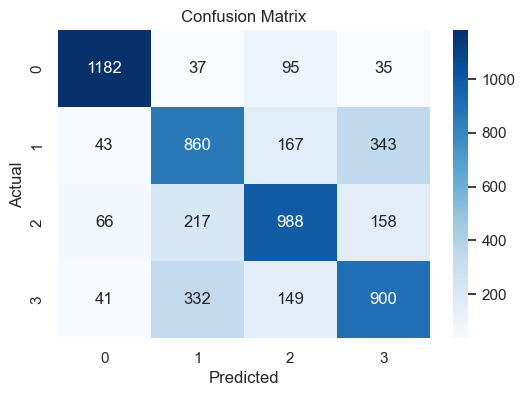

Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.88      0.88      1349
           2       0.59      0.61      0.60      1413
           3       0.71      0.69      0.70      1429
           4       0.63      0.63      0.63      1422

    accuracy                           0.70      5613
   macro avg       0.70      0.70      0.70      5613
weighted avg       0.70      0.70      0.70      5613



In [308]:
accuracy = accuracy_score(y_test_resampled, y_pred)
print(f"Accuracy: {accuracy:.2f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_resampled, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_test_resampled, y_pred)
print("Classification Report:")
print(class_report)

## RANDOM FOREST

In [251]:
rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [253]:
from sklearn.metrics import precision_score,recall_score,f1_score
y_pred = rf_classifier.predict(X_test)
Eval_Rf= classification_task(rf_classifier,X_train, y_train ,X_test ,y_test, y_pred ,'Random Forest')
Eval_Rf

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
Random Forest,0.999596,0.907299,0.898836,0.907299,0.899141,0.907299


Accuracy: 0.91


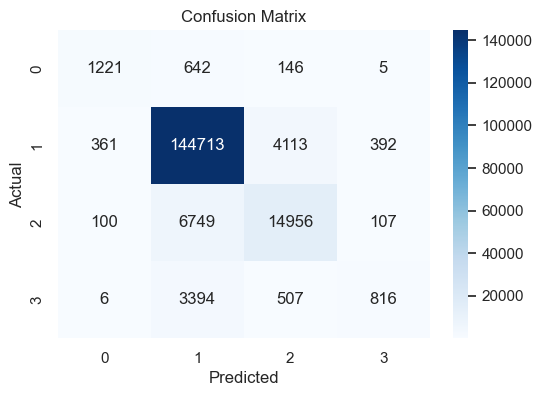

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.61      0.66      2014
           2       0.93      0.97      0.95    149579
           3       0.76      0.68      0.72     21912
           4       0.62      0.17      0.27      4723

    accuracy                           0.91    178228
   macro avg       0.76      0.61      0.65    178228
weighted avg       0.90      0.91      0.90    178228



In [255]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

## GRADIENT BOOSTING

In [336]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 198.2 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [342]:
(y_train-1).unique()

array([1, 2, 0, 3])

In [364]:
df2.head()

,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,County,...,Weather_year,Start_Hour,Start_Mins,Start_seconds,End_Hour,End_Mins,End_seconds,Weather_Hour,Weather_Mins,Weather_seconds
0,Source2,3,05:46:00,0 days 11:00:00,39.865147,-84.058723,0.01,I-70 E,Dayton,Montgomery,...,2016,05,46,00,0 days 11,00,00,0 days 05,58,00
1,Source2,2,06:07:59,0 days 06:37:59,39.928059,-82.831184,0.01,Brice Rd,Reynoldsburg,Franklin,...,2016,06,07,59,0 days 06,37,59,0 days 05,51,00
2,Source2,2,06:49:27,0 days 07:19:27,39.063148,-84.032608,0.01,State Route 32,Williamsburg,Clermont,...,2016,06,49,27,0 days 07,19,27,0 days 06,56,00
3,Source2,3,07:23:34,0 days 07:53:34,39.747753,-84.205582,0.01,I-75 S,Dayton,Montgomery,...,2016,07,23,34,0 days 07,53,34,0 days 07,38,00
4,Source2,2,07:39:07,0 days 08:09:07,39.627781,-84.188354,0.01,Miamisburg Centerville Rd,Dayton,Montgomery,...,2016,07,39,07,0 days 08,09,07,0 days 07,53,00


In [368]:
xgb_classifier = XGBClassifier(objective='multi:softmax',random_state=42)
xgb_classifier.fit(X_resampled_under, y_resampled_under-1 )y_pred = xgb_classifier.predict(X_test_resampled)
Eval_xgb=classification_task(xgb_classifier,X_resampled_under, y_resampled_under-1 ,X_test_resampled,y_test_resampled-1, y_pred,'XGBoost')
Eval_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softmax', ...)

In [370]:
y_pred = xgb_classifier.predict(X_test_resampled)
Eval_xgb=classification_task(xgb_classifier,X_resampled_under, y_resampled_under-1 ,X_test_resampled,y_test_resampled-1, y_pred,'XGBoost')
Eval_xgb

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
XGBoost,0.978543,0.782113,0.779631,0.782113,0.779624,0.782113


Accuracy: 0.78


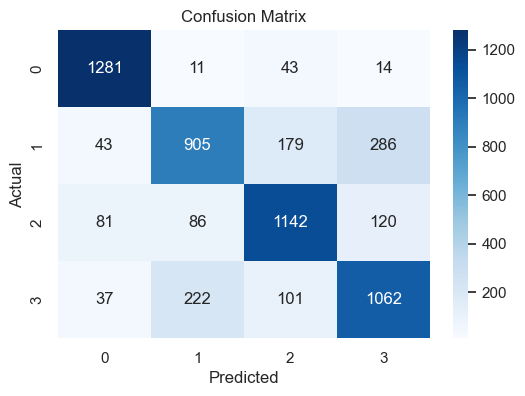

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1349
           1       0.74      0.64      0.69      1413
           2       0.78      0.80      0.79      1429
           3       0.72      0.75      0.73      1422

    accuracy                           0.78      5613
   macro avg       0.78      0.78      0.78      5613
weighted avg       0.78      0.78      0.78      5613



In [403]:
accuracy = accuracy_score(y_test_resampled-1, y_pred)
print(f"Accuracy: {accuracy:.2f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_resampled-1, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_test_resampled-1, y_pred)
print("Classification Report:")
print(class_report)

# REGRESSION (PREDICTING COUNTS)

## LINEAR REGRESSION

Linear Regression MSE: 0.18890229254239566
Linear Regression R^2: 0.11369861388741553


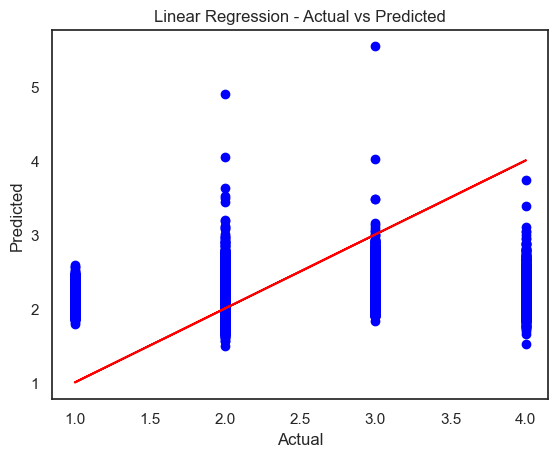

In [354]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

# Evaluation Metrics
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))
print("Linear Regression R^2:", r2_score(y_test, y_pred))

# Actual vs Predicted Plot
plt.scatter(y_test, y_pred, color='blue')
plt.plot(y_test, y_test, color='red')  # 45-degree line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

## POISSON REGRESSION

In [356]:
from sklearn.linear_model import PoissonRegressor

# Poisson Regression Model
pois_reg = PoissonRegressor()
pois_reg.fit(X_train, y_train)
y_pred = pois_reg.predict(X_test)

# Evaluation Metrics
print("Poisson Regression MSE:", mean_squared_error(y_test, y_pred))
print("Poisson Regression R^2:", r2_score(y_test, y_pred))

Poisson Regression MSE: 0.21313659162714946
Poisson Regression R^2: -5.103421699237387e-06


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


## RANDOM FOREST REGRESSOR

In [408]:
rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [410]:
from sklearn.metrics import precision_score,recall_score,f1_score
y_pred = rf_classifier.predict(X_test)
Eval_Rf= classification_task(rf_classifier,X_train, y_train ,X_test ,y_test, y_pred ,'Random Forest')
Eval_Rf

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
Random Forest,0.999596,0.907299,0.898836,0.907299,0.899141,0.907299


Accuracy: 0.91


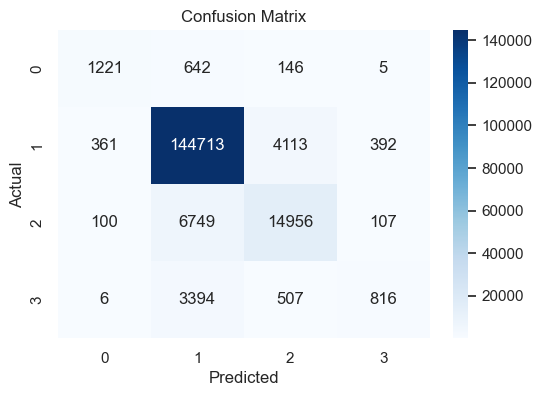

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.61      0.66      2014
           1       0.93      0.97      0.95    149579
           2       0.76      0.68      0.72     21912
           3       0.62      0.17      0.27      4723

    accuracy                           0.91    178228
   macro avg       0.76      0.61      0.65    178228
weighted avg       0.90      0.91      0.90    178228



In [412]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

## VOTING

In [426]:
voting_classifier = VotingClassifier(estimators=[
    ('dt_classifier',dt_classifier),
    ('rf_classifier',rf_classifier),
    ('xgb', xgb_classifier),
    ('logreg',logistic_regression)
], voting='soft') 

voting_classifier.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('dt_classifier',
                              DecisionTreeClassifier(random_state=42)),
                             ('rf_classifier',
                              RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metr...
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            objective='multi:softmax', ...)),
                             ('logreg', LogisticRegression(random_state=42))],
                 voting='soft')

In [437]:
y_pred = voting_classifier.predict(X_test)

Eval_voting=classification_task(voting_classifier,X_train, y_train ,X_test,y_test, y_pred,'voting')
Eval_voting

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
voting,0.985685,0.897945,0.887329,0.897945,0.887361,0.897945


## MODEL COMPARISON TABLE

In [447]:
pd.concat([Eval_voting, Eval_xgb ,Eval_Rf,Eval_Dt,Eval_logreg])

,Train_Score,Test_Score,Precision_Score,Recall_Score,F1_Score,accuracy
voting,0.985685,0.897945,0.887329,0.897945,0.887361,0.897945
XGBoost,0.978543,0.782113,0.779631,0.782113,0.779624,0.782113
Random Forest,0.999596,0.907299,0.898836,0.907299,0.899141,0.907299
Decision Trees,1.000000,0.700160,0.701563,0.700160,0.700809,0.700160
logreg,0.634010,0.636558,0.630243,0.636558,0.630501,0.636558
